In [5]:
!pip install pandas numpy scipy scikit-learn matplotlib seaborn nltk pillow opencv-python wfdb

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

PIMA_URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
pima_cols = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]

df = pd.read_csv(PIMA_URL, names=pima_cols)
print("\nPIMA SHAPE:", df.shape)
print("\nCLASS COUNTS:\n", df["Outcome"].value_counts())
print("\nDESCRIPTIVE STATISTICS:\n", df.describe().round(2))

# Healthcare-aware missingness:
# In this dataset, zero can represent missing/not-recorded values for
# Glucose, BloodPressure, SkinThickness, Insulin and BMI.
zero_missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df_clean = df.copy()
df_clean[zero_missing] = df_clean[zero_missing].replace(0, np.nan)

print("\nMISSING VALUES AFTER ZERO-TO-NA CONVERSION:\n",
      df_clean.isna().sum())

# Median imputation avoids losing many observations.
for col in zero_missing:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Basic feature engineering
df_clean["BMI_Age"] = df_clean["BMI"] * df_clean["Age"]
df_clean["Glucose_Age"] = df_clean["Glucose"] * df_clean["Age"]

# EDA
sns.countplot(data=df_clean, x="Outcome")
plt.title("Pima Diabetes Outcome Distribution")
plt.tight_layout()
plt.savefig("pima_outcome_distribution.png", dpi=200)
plt.close()

plt.figure(figsize=(10, 7))
sns.heatmap(df_clean.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Pima Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("pima_correlation_heatmap.png", dpi=200)
plt.close()

# ---------- Hypothesis test ----------
# H0: Mean glucose is equal for the two outcome groups.
# H1: Mean glucose differs between the two groups.
g0 = df_clean.loc[df_clean["Outcome"] == 0, "Glucose"]
g1 = df_clean.loc[df_clean["Outcome"] == 1, "Glucose"]
t_stat, p_value = stats.ttest_ind(g0, g1, equal_var=False)
print("\nWelch t-test: glucose by outcome")
print("t =", round(t_stat, 4), "p =", p_value)

# ---------- Chi-square test ----------
# Convert age to clinically interpretable broad groups.
df_clean["AgeGroup"] = pd.cut(
    df_clean["Age"],
    bins=[20, 30, 40, 50, 100],
    labels=["21-30", "31-40", "41-50", "51+"],
    include_lowest=True
)
contingency = pd.crosstab(df_clean["AgeGroup"], df_clean["Outcome"])
chi2_stat, chi_p, dof, expected = stats.chi2_contingency(contingency)
print("\nChi-square test: AgeGroup vs Outcome")
print(contingency)
print("chi2 =", round(chi2_stat, 4), "df =", dof, "p =", chi_p)

# ---------- One-way ANOVA ----------
# H0: Mean glucose is equal across age groups.
# H1: At least one age group has a different mean glucose.
anova_groups = [
    group["Glucose"].dropna().values
    for _, group in df_clean.groupby("AgeGroup", observed=True)
]
f_stat, anova_p = stats.f_oneway(*anova_groups)
print("\nOne-way ANOVA: Glucose across AgeGroup")
print("F =", round(f_stat, 4), "p =", anova_p)

# ---------- Feature selection ----------
X = df_clean.drop(columns=["Outcome", "AgeGroup"])
y = df_clean["Outcome"]
X_num = X.select_dtypes(include=np.number)
X_scaled = StandardScaler().fit_transform(X_num)

selector = SelectKBest(score_func=chi2, k=min(5, X_num.shape[1]))
# chi2 requires non-negative features, so use MinMax-style shifting.
X_nonnegative = X_num - X_num.min()
X_selected = selector.fit_transform(X_nonnegative, y)
print("\nSelected features:",
      list(X_num.columns[selector.get_support()]))

# PCA feature extraction
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print("PCA explained variance:", pca.explained_variance_ratio_)

# Simple model-ready split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)
print("\nRandom Forest classification report:")
print(classification_report(y_test, pred))



PIMA SHAPE: (768, 9)

CLASS COUNTS:
 Outcome
0    500
1    268
Name: count, dtype: int64

DESCRIPTIVE STATISTICS:
        Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  \
count       768.00   768.00         768.00         768.00   768.00  768.00   
mean          3.85   120.89          69.11          20.54    79.80   31.99   
std           3.37    31.97          19.36          15.95   115.24    7.88   
min           0.00     0.00           0.00           0.00     0.00    0.00   
25%           1.00    99.00          62.00           0.00     0.00   27.30   
50%           3.00   117.00          72.00          23.00    30.50   32.00   
75%           6.00   140.25          80.00          32.00   127.25   36.60   
max          17.00   199.00         122.00          99.00   846.00   67.10   

       DiabetesPedigreeFunction     Age  Outcome  
count                    768.00  768.00   768.00  
mean                       0.47   33.24     0.35  
std                        0

In [14]:
# Uploaded files: ['mtsamples.csv']

In [16]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, chi2

# ============================================================
# PART B – TEXTUAL DATA: MTSAMPLES MEDICAL TRANSCRIPTIONS
# ============================================================

# Download mtsamples.csv from the dataset page listed in the report.
# Set MTSAMPLES_PATH to the local CSV path.
MTSAMPLES_PATH = "mtsamples.csv"

if os.path.exists(MTSAMPLES_PATH):
    text_df = pd.read_csv(MTSAMPLES_PATH, engine='python') # Using python engine for robustness
    print("\nMTSAMPLES SHAPE:", text_df.shape)
    print("\nCOLUMNS:", list(text_df.columns))
    print("\nMISSING VALUES:\n", text_df.isna().sum())

    # Remove rows without transcription or specialty.
    text_df = text_df.dropna(subset=["transcription", "medical_specialty"]).copy()

    # Basic PHI-oriented cleaning. This is a conservative pattern-based pass;
    # real clinical deployment requires dedicated de-identification validation.
    def clean_text(x):
        x = str(x)
        x = re.sub(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", "[EMAIL]", x)
        x = re.sub(r"\b(?:\+?\d[\d\s\-\(\)]{7,}\d)\b", "[PHONE]", x)
        x = re.sub(r"\b(?:MRN|medical record number)\s*[:#]?\s*\w+\b",
                   "[MRN]", x, flags=re.I)
        x = re.sub(r"\s+", " ", x).strip().lower()
        return x

    text_df["clean_text"] = text_df["transcription"].map(clean_text)

    # EDA: specialty frequency
    specialty_counts = text_df["medical_specialty"].value_counts().head(15)
    print("\nTOP 15 SPECIALTIES:\n", specialty_counts)

    specialty_counts.sort_values().plot(kind="barh", figsize=(8, 6))
    plt.title("Top Medical Specialties in MTSamples")
    plt.tight_layout()
    plt.savefig("mtsamples_top_specialties.png", dpi=200)
    plt.close()

    # Token/character statistics
    text_df["char_count"] = text_df["clean_text"].str.len()
    text_df["word_count"] = text_df["clean_text"].str.split().str.len()
    print("\nTEXT LENGTH SUMMARY:\n",
          text_df[["char_count", "word_count"]].describe().round(2))

    # TF-IDF model-ready representation
    vectorizer = TfidfVectorizer(
        max_features=2000,
        ngram_range=(1, 2),
        min_df=2,
        stop_words="english"
    )
    X_text = vectorizer.fit_transform(text_df["clean_text"])
    print("\nTF-IDF matrix shape:", X_text.shape)

    # Feature selection with chi-square against specialty
    le = LabelEncoder()
    y_text = le.fit_transform(text_df["medical_specialty"])
    k = min(500, X_text.shape[1])
    X_text_selected = SelectKBest(chi2, k=k).fit_transform(X_text, y_text)
    print("Selected TF-IDF feature matrix:", X_text_selected.shape)

else:
    print("\nMTSamples file not found. Download mtsamples.csv and rerun Part B.")


MTSAMPLES SHAPE: (4999, 6)

COLUMNS: ['Unnamed: 0', 'description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']

MISSING VALUES:
 Unnamed: 0              0
description             0
medical_specialty       0
sample_name             0
transcription          33
keywords             1068
dtype: int64

TOP 15 SPECIALTIES:
 medical_specialty
Surgery                          1088
Consult - History and Phy.        516
Cardiovascular / Pulmonary        371
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  224
Neurology                         223
SOAP / Chart / Progress Notes     166
Urology                           156
Obstetrics / Gynecology           155
Discharge Summary                 108
ENT - Otolaryngology               96
Neurosurgery                       94
Hematology - Oncology              90
Name: count, dtype: int64

TEXT LENGTH SUMMARY:
        char_count  wo

In [22]:
# PART C - Chest X-Ray preprocessing demonstration

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps, ImageEnhance
from io import BytesIO
from google.colab import files

print("Upload 2-4 chest X-ray images")
print("Try to include both NORMAL and PNEUMONIA images.")

uploaded = files.upload()

images = []

for filename, data in uploaded.items():
    try:
        img = Image.open(BytesIO(data)).convert("L")
        images.append((filename, img))
        print(filename, "Original size:", img.size)
    except:
        print(filename, "is not a valid image.")

print("Total images:", len(images))

Upload 2-4 chest X-ray images
Try to include both NORMAL and PNEUMONIA images.


Saving Screenshot 2026-08-31 at 11.45.10 AM.png to Screenshot 2026-08-31 at 11.45.10 AM (1).png
Saving Screenshot 2026-08-31 at 11.45.22 AM.png to Screenshot 2026-08-31 at 11.45.22 AM (1).png
Screenshot 2026-08-31 at 11.45.10 AM (1).png Original size: (1856, 1732)
Screenshot 2026-08-31 at 11.45.22 AM (1).png Original size: (2072, 1672)
Total images: 2


Screenshot 2026-08-31 at 11.45.10 AM (1).png
Original size: (1856, 1732)
New size: (224, 224)
Pixel range: 0.0 to 1.0

Screenshot 2026-08-31 at 11.45.22 AM (1).png
Original size: (2072, 1672)
New size: (224, 224)
Pixel range: 0.0 to 0.9764706



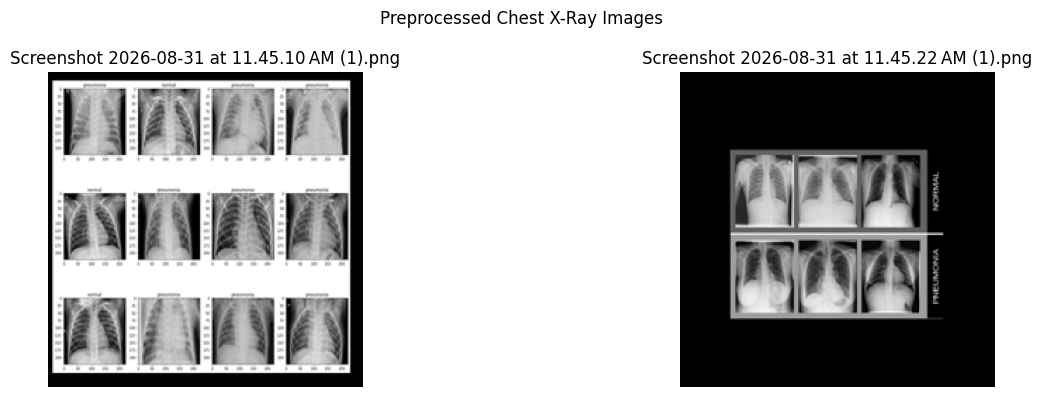

In [23]:
# PART C - Image preprocessing

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps, ImageEnhance

processed = []

for filename, img in images:
    # Resize
    resized = img.resize((224, 224))

    # Normalize pixel values to 0-1
    normalized = np.asarray(resized, dtype=np.float32) / 255.0

    processed.append((filename, resized, normalized))

    print(filename)
    print("Original size:", img.size)
    print("New size:", resized.size)
    print("Pixel range:", normalized.min(), "to", normalized.max())
    print()

# Display processed images
fig, axes = plt.subplots(1, len(processed), figsize=(15, 4))

if len(processed) == 1:
    axes = [axes]

for ax, (filename, resized, normalized) in zip(axes, processed):
    ax.imshow(normalized, cmap="gray")
    ax.set_title(filename)
    ax.axis("off")

plt.suptitle("Preprocessed Chest X-Ray Images")
plt.tight_layout()
plt.show()

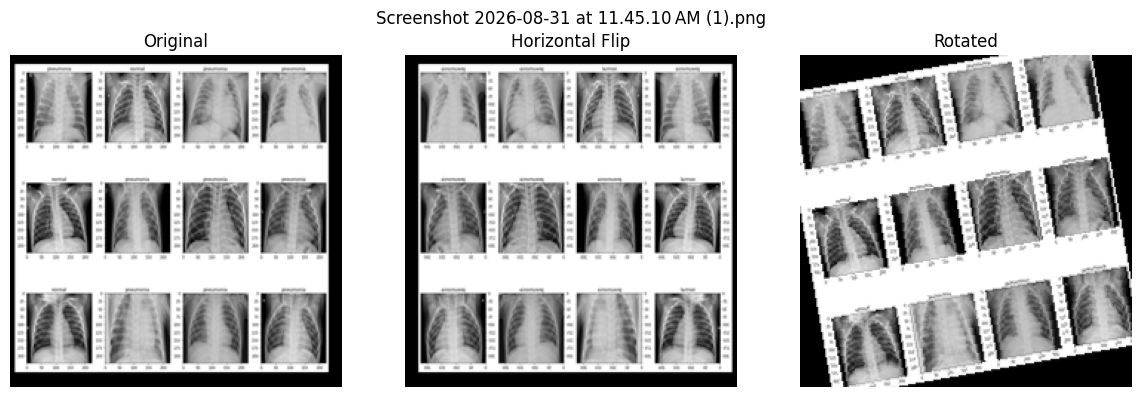

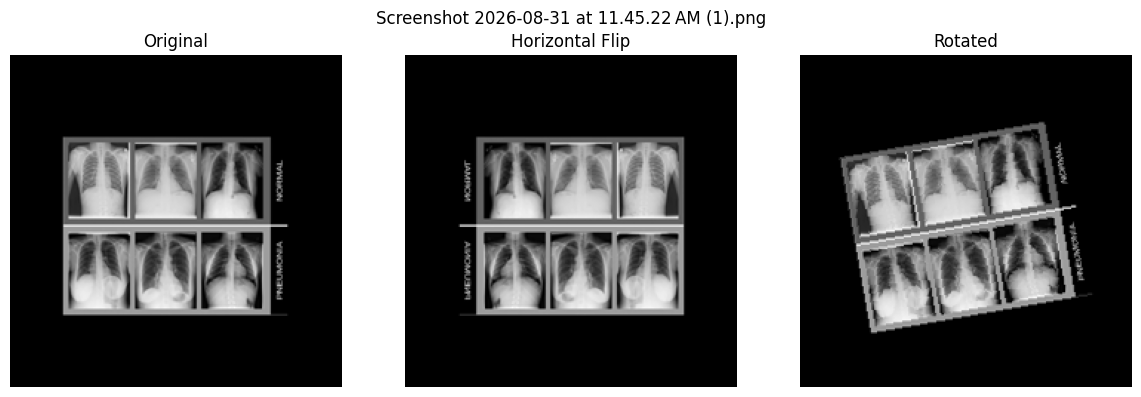

In [24]:
# PART C - Image Augmentation

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

for filename, img in images:
    # Resize first
    img = img.resize((224, 224))

    # Horizontal flip = simple augmentation
    flipped = ImageOps.mirror(img)

    # Slight rotation = another augmentation
    rotated = img.rotate(10)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(img, cmap="gray")
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(flipped, cmap="gray")
    axes[1].set_title("Horizontal Flip")
    axes[1].axis("off")

    axes[2].imshow(rotated, cmap="gray")
    axes[2].set_title("Rotated")
    axes[2].axis("off")

    plt.suptitle(filename)
    plt.tight_layout()
    plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 5.5 MB/s eta 0:00:00


Saving 100.atr to 100.atr
Uploaded files: ['100.atr']

===== ECG RECORD INFORMATION =====
Record: 100
Sampling frequency: 360 Hz
Number of samples: 650000
Number of channels: 2

===== ANNOTATION INFORMATION =====
Number of annotations: 2274
First 20 annotation samples: [  18   77  370  662  946 1231 1515 1809 2044 2402 2706 2998 3282 3560
 3862 4170 4466 4764 5060 5346]
First 20 annotation symbols: ['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


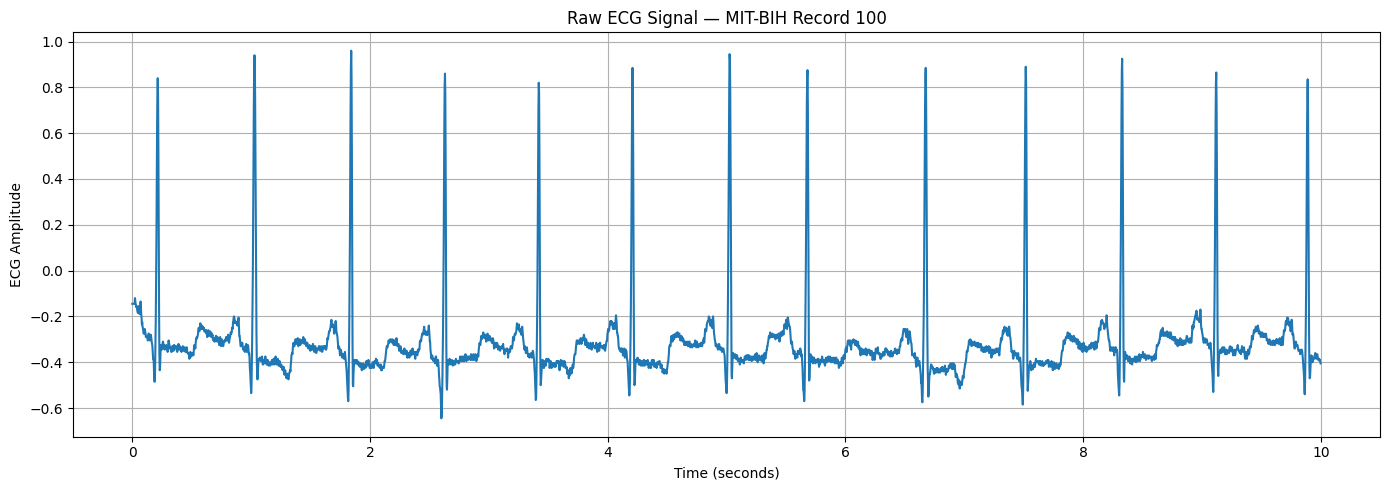

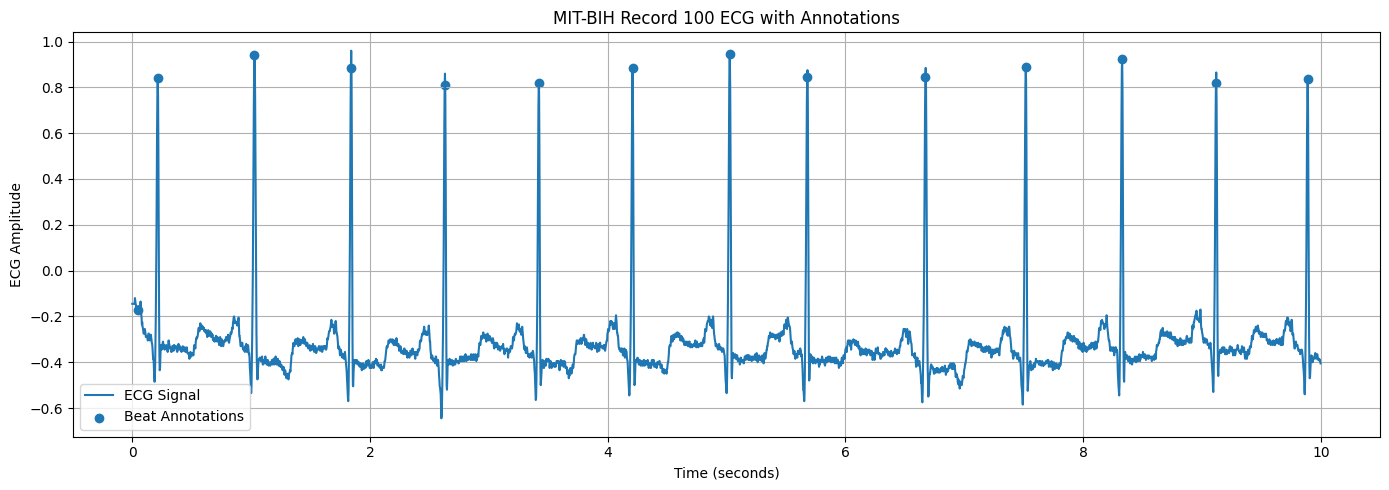


===== ANNOTATION COUNTS =====


,Annotation,Count
1,N,2239
2,A,33
0,+,1
3,V,1


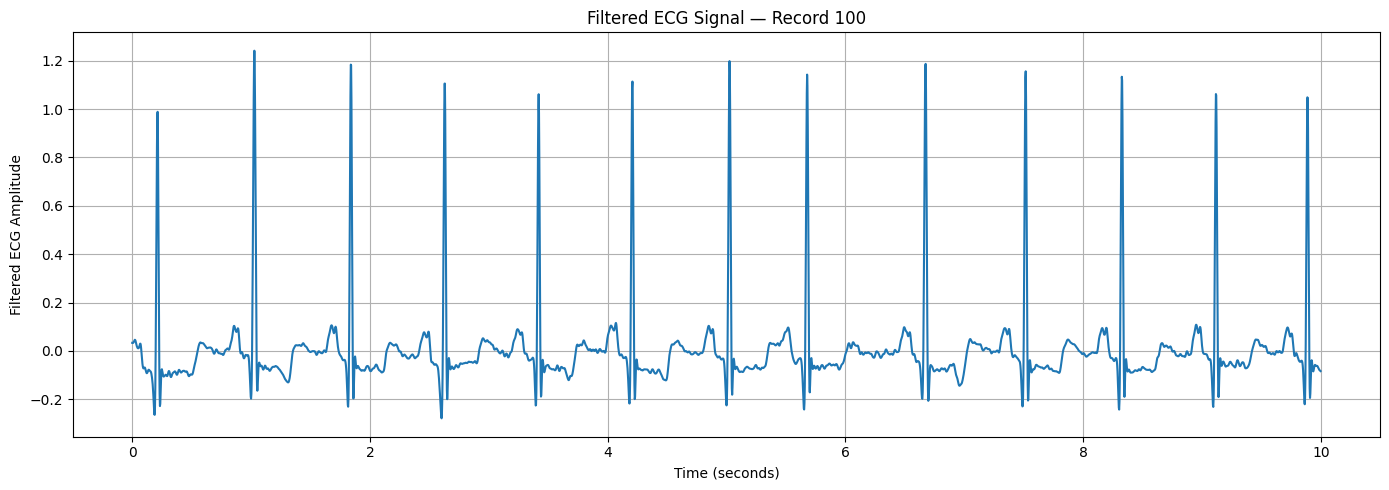

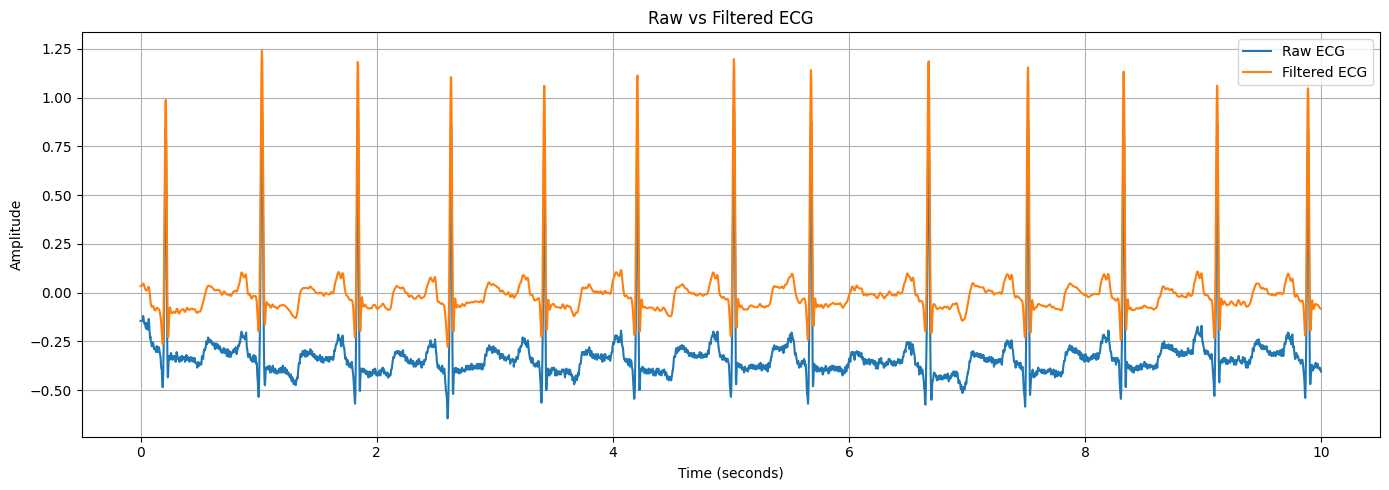


===== WINDOWING =====
Window duration: 5 seconds
Samples per window: 1800
Window matrix shape: (20, 1800)

===== EXTRACTED FEATURES =====


,mean,std,min,max,range,rms
0,-0.003194,0.159633,-0.278717,1.240993,1.519710,0.159665
1,0.002878,0.170659,-0.242458,1.198003,1.440461,0.170683
2,-0.001033,0.157981,-0.256442,1.168682,1.425124,0.157984
3,-0.001912,0.168449,-0.245797,1.258394,1.504191,0.168460
4,0.000060,0.170082,-0.261643,1.316599,1.578243,0.170082
5,-0.000154,0.172482,-0.259922,1.405827,1.665749,0.172482
6,0.001331,0.167485,-0.261041,1.318727,1.579768,0.167490
7,0.000250,0.166500,-0.286869,1.259491,1.546361,0.166501
8,0.002950,0.173214,-0.261451,1.284880,1.546330,0.173239
9,-0.002302,0.171842,-0.262922,1.326573,1.589495,0.171857



PART D COMPLETED SUCCESSFULLY
ECG Record: MIT-BIH Record 100
Sampling Rate: 360 Hz
Total ECG Samples: 650000
Total Annotations: 2274
Number of Windows: 20
Window Size: 5 seconds
Feature Matrix Shape: (20, 6)

Feature columns:
['mean', 'std', 'min', 'max', 'range', 'rms']


In [1]:
# ============================================================
# PART D — SIGNAL DATA: MIT-BIH ARRHYTHMIA DATABASE (ECG)
# ============================================================

# 1. Install required libraries
!pip -q install wfdb

# 2. Import libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb

from scipy.signal import butter, filtfilt

# ------------------------------------------------------------
# 3. Upload 100.atr annotation file
# ------------------------------------------------------------

from google.colab import files

uploaded = files.upload()

print("Uploaded files:", list(uploaded.keys()))

# ------------------------------------------------------------
# 4. Download/read MIT-BIH Record 100
# ------------------------------------------------------------

record = wfdb.rdrecord("100", pn_dir="mitdb")

signal = record.p_signal[:, 0]
fs = record.fs

print("\n===== ECG RECORD INFORMATION =====")
print("Record:", "100")
print("Sampling frequency:", fs, "Hz")
print("Number of samples:", len(signal))
print("Number of channels:", record.n_sig)

# ------------------------------------------------------------
# 5. Read 100.atr annotation file
# ------------------------------------------------------------

ann = wfdb.rdann("100", "atr", pn_dir="mitdb")

print("\n===== ANNOTATION INFORMATION =====")
print("Number of annotations:", len(ann.sample))
print("First 20 annotation samples:", ann.sample[:20])
print("First 20 annotation symbols:", ann.symbol[:20])

# ------------------------------------------------------------
# 6. Plot raw ECG signal
# ------------------------------------------------------------

display_seconds = 10
n = int(display_seconds * fs)

time = np.arange(n) / fs

plt.figure(figsize=(14, 5))
plt.plot(time, signal[:n])
plt.xlabel("Time (seconds)")
plt.ylabel("ECG Amplitude")
plt.title("Raw ECG Signal — MIT-BIH Record 100")
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. Plot ECG with beat annotations
# ------------------------------------------------------------

annotation_mask = ann.sample < n

plt.figure(figsize=(14, 5))

plt.plot(
    time,
    signal[:n],
    label="ECG Signal"
)

plt.scatter(
    ann.sample[annotation_mask] / fs,
    signal[ann.sample[annotation_mask]],
    marker="o",
    label="Beat Annotations"
)

plt.xlabel("Time (seconds)")
plt.ylabel("ECG Amplitude")
plt.title("MIT-BIH Record 100 ECG with Annotations")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. Count annotation / beat types
# ------------------------------------------------------------

from collections import Counter

annotation_counts = Counter(ann.symbol)

annotation_table = pd.DataFrame(
    list(annotation_counts.items()),
    columns=["Annotation", "Count"]
).sort_values("Count", ascending=False)

print("\n===== ANNOTATION COUNTS =====")
display(annotation_table)

# ------------------------------------------------------------
# 9. Band-pass filtering / noise removal
# ------------------------------------------------------------

def bandpass_filter(x, fs, low=0.5, high=40.0, order=4):

    nyquist = fs / 2

    b, a = butter(
        order,
        [low / nyquist, high / nyquist],
        btype="band"
    )

    return filtfilt(b, a, x)


filtered_signal = bandpass_filter(signal, fs)

# ------------------------------------------------------------
# 10. Plot filtered ECG
# ------------------------------------------------------------

plt.figure(figsize=(14, 5))

plt.plot(
    time,
    filtered_signal[:n]
)

plt.xlabel("Time (seconds)")
plt.ylabel("Filtered ECG Amplitude")
plt.title("Filtered ECG Signal — Record 100")
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 11. Compare Raw vs Filtered ECG
# ------------------------------------------------------------

plt.figure(figsize=(14, 5))

plt.plot(
    time,
    signal[:n],
    label="Raw ECG"
)

plt.plot(
    time,
    filtered_signal[:n],
    label="Filtered ECG"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Raw vs Filtered ECG")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 12. Create 5-second ECG windows
# ------------------------------------------------------------

window_seconds = 5
window_size = int(window_seconds * fs)

windows = []

for start in range(
    0,
    len(filtered_signal) - window_size + 1,
    window_size
):

    windows.append(
        filtered_signal[start:start + window_size]
    )

    # Keep first 20 windows for demonstration
    if len(windows) >= 20:
        break


windows = np.asarray(windows)

print("\n===== WINDOWING =====")
print("Window duration:", window_seconds, "seconds")
print("Samples per window:", window_size)
print("Window matrix shape:", windows.shape)

# ------------------------------------------------------------
# 13. Extract statistical features
# ------------------------------------------------------------

features = pd.DataFrame({

    "mean": windows.mean(axis=1),

    "std": windows.std(axis=1),

    "min": windows.min(axis=1),

    "max": windows.max(axis=1),

    "range": windows.max(axis=1) - windows.min(axis=1),

    "rms": np.sqrt(
        np.mean(windows ** 2, axis=1)
    )
})

print("\n===== EXTRACTED FEATURES =====")
display(features.head(10))

# ------------------------------------------------------------
# 14. Final summary
# ------------------------------------------------------------

print("\n================================================")
print("PART D COMPLETED SUCCESSFULLY")
print("================================================")

print("ECG Record:", "MIT-BIH Record 100")
print("Sampling Rate:", fs, "Hz")
print("Total ECG Samples:", len(signal))
print("Total Annotations:", len(ann.sample))
print("Number of Windows:", len(windows))
print("Window Size:", window_seconds, "seconds")
print("Feature Matrix Shape:", features.shape)

print("\nFeature columns:")
print(list(features.columns))